<h1>
<font color="#1565C0">
Building a Regression MLP Using the Sequential API
</font>
</h1>

<hr>

<h2>
<font color="#2E7D32">
Introduction
</font>
</h2>

<p>
In this section, we will tackle the
<b><font color="#F57C00">California Housing Problem</font></b>
using a
<b><font color="#D32F2F">Regression Neural Network</font></b>.

Unlike classification tasks, regression allows us to predict
<b><font color="#388E3C">continuous numerical values</font></b>
(such as house prices).
</p>

<hr>

<h2>
<font color="#2E7D32">
Dataset Overview
</font>
</h2>

<p>
We will use the
<code>fetch_california_housing()</code>
function from
<b><font color="#1565C0">Scikit-Learn</font></b>
to load the dataset.
</p>

<h3>
<font color="#1976D2">
Key Characteristics
</font>
</h3>

<ul>

<li>
<b><font color="#F57C00">Simple Features:</font></b>
Contains only numerical features (no categorical data such as
<code>ocean_proximity</code>).
</li>

<br>

<li>
<b><font color="#388E3C">Clean Data:</font></b>
There are no missing values, which simplifies the preprocessing steps.
</li>

</ul>

<hr>

<h2>
<font color="#2E7D32">
Learning Path
</font>
</h2>

<p>
To build an effective model, we will follow these essential steps:
</p>

<ol>

<li>
<b><font color="#1565C0">Data Loading</font></b><br>
Fetching the dataset using Scikit-Learn.
</li>

<br>

<li>
<b><font color="#1565C0">Data Splitting</font></b><br>
Dividing the data into
<b>Training</b>,
<b>Validation</b>, and
<b>Test</b>
sets to ensure proper model generalization.
</li>

<br>

<li>
<b><font color="#1565C0">Feature Scaling</font></b><br>
Standardizing the numerical ranges of all features to help the neural network converge faster during training.
</li>

</ol>

<hr>

<p align="center">
<b><font color="#C62828">
Objective:
</font></b>
Build, train, and evaluate a Regression MLP for predicting California house prices.
</p>

In [ ]:
!pip install --upgrade tensorflow

In [1]:
import tensorflow as tf
from tensorflow import keras



In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
# Step 1: Fetch the California housing dataset from sklearn's library
housing = fetch_california_housing()

In [5]:
# Step 2: Split the data into a training set and a test set (default 75/25 split)
x_train_full, x_test, y_train_full, y_test = train_test_split(housing.data, housing.target)

# Step 3: Split the training set again to create a validation set for monitoring performance during training
x_train, x_valid, y_train, y_valid = train_test_split(x_train_full, y_train_full)

In [6]:
# Step 4: Initialize the StandardScaler to normalize our features (mean=0, variance=1)
scalar = StandardScaler()

In [7]:
# Step 5: Fit the scaler on training data and transform all subsets
# Note: Use fit_transform only on training data, and transform on validation/test
x_train_scaled = scalar.fit_transform(x_train)
x_valid_scaled = scalar.transform(x_valid)
x_test_scaled = scalar.transform(x_test)

<h2>
<font color="#2E7D32">
Key Concepts: Regression vs. Classification MLPs
</font>
</h2>

<p>
When building a
<b><font color="#D32F2F">Regression MLP</font></b>
using the
<b><font color="#1565C0">Sequential API</font></b>,
there are several important differences compared to
<b><font color="#F57C00">Classification MLPs</font></b>.
Understanding these differences helps in designing an effective neural network for predicting
<b><font color="#388E3C">continuous numerical values</font></b>.
</p>

<hr>

<h3>
<font color="#1976D2">
Key Differences
</font>
</h3>

<ul>

<li>
<b><font color="#F57C00">Output Layer:</font></b><br>
Regression models predict a
<b>single continuous numerical value</b>.
Therefore, the output layer contains
<b>one neuron</b>
and generally uses
<b>no activation function</b>
(<code>activation=None</code> or linear activation),
allowing predictions across the entire real number line.
</li>

<br>

<li>
<b><font color="#388E3C">Loss Function:</font></b><br>
Instead of classification losses such as
<code>categorical_crossentropy</code>,
regression models commonly use
<b>Mean Squared Error (MSE)</b>.
MSE penalizes larger prediction errors more heavily, making it well-suited for numerical prediction tasks.
</li>

<br>

<li>
<b><font color="#1565C0">Architecture Design:</font></b><br>
Real-world regression datasets often contain
<b>noise</b>.
To reduce the risk of
<b>overfitting</b>,
it is generally recommended to begin with a
<b>simple network architecture</b>,
such as a single hidden layer with a moderate number of neurons, before increasing model complexity.
</li>

</ul>

<hr>

<p align="center">
<b><font color="#C62828">
Takeaway:
</font></b>
Regression MLPs differ from classification networks primarily in their
<b>output layer</b>,
<b>loss function</b>,
and
<b>model complexity</b>,
all of which are tailored for predicting continuous numerical values.
</p>

In [8]:
model = keras.models.Sequential([
    keras.layers.Dense(30 , activation = "relu", input_shape = x_train.shape[1:]),
    keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(loss = "mean_squared_error", optimizer="sgd")

In [12]:
history = model.fit(x_train, y_train , epochs=20, validation_data=(x_valid, y_valid))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 753052687699642037869477888.0000 - val_loss: 459924060233212624896.0000
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 32011621335721574400.0000 - val_loss: 196253430317056.0000
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 13659635974144.0000 - val_loss: 83743040.0000
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5828670.5000 - val_loss: 37.2789
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 3.8623 - val_loss: 1.2885
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3527 - val_loss: 1.2882
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.3524 - val_loss: 1.2878
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.3521 - val_loss: 1.2886
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.3529 - val_loss: 1.2879
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.3526 - val_loss: 1.2885
Epoch 11/20
363/363 ━━━━━━━━━━━━━

In [14]:
mse_test = model.evaluate(x_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3186


In [15]:
# pretend these are new instances
x_new = x_test[:3]

In [16]:
y_pred = model.predict(x_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


In [17]:
y_pred

array([[2.082254],
       [2.082254],
       [2.082254]], dtype=float32)

<h2>
<font color="#2E7D32">
Building Complex Models Using the Functional API
</font>
</h2>

<p>
The
<b><font color="#1565C0">Sequential API</font></b>
is ideal for building simple neural networks where layers are connected in a
<b><font color="#388E3C">linear sequence</font></b>.
However, many real-world deep learning problems require more flexible architectures.
For these scenarios,
<b><font color="#D32F2F">Keras Functional API</font></b>
provides a powerful way to design complex neural networks.
</p>

<hr>

<h3>
<font color="#1976D2">
Why Use the Functional API?
</font>
</h3>

<p>
Unlike the Sequential API, where each layer has exactly
<b>one input</b>
and
<b>one output</b>,
the Functional API allows layers to be connected in
<b>multiple directions</b>,
making it possible to build advanced neural network architectures.
</p>

<ul>

<li>
<b><font color="#F57C00">Multi-Input Models:</font></b><br>
Combine different types of input data, such as numerical features, images, or text, within a single model.
</li>

<br>

<li>
<b><font color="#388E3C">Multi-Output Models:</font></b><br>
Predict multiple target variables simultaneously using separate output layers.
</li>

<br>

<li>
<b><font color="#1565C0">Non-Linear Topologies:</font></b><br>
Create networks with branching, merging, skip connections, or shared layers that cannot be represented using the Sequential API.
</li>

</ul>

<hr>

<h3>
<font color="#1976D2">
Wide &amp; Deep Learning Architecture
</font>
</h3>

<p>
A well-known example of a
<b><font color="#D32F2F">non-sequential architecture</font></b>
is the
<b><font color="#1565C0">Wide &amp; Deep Neural Network</font></b>,
introduced by
<b>Heng-Tze Cheng et al.</b>
in 2016.
This architecture combines the strengths of both
<b>memorization</b>
and
<b>generalization</b>
within a single model.
</p>

<h4>
<font color="#388E3C">
How It Works
</font>
</h4>

<ul>

<li>
<b><font color="#F57C00">Wide Path (Short Path):</font></b><br>
Some or all of the input features are connected
<b>directly to the output layer</b>.
This enables the model to learn simple relationships and memorize important patterns without passing through multiple hidden layers.
</li>

<br>

<li>
<b><font color="#1565C0">Deep Path:</font></b><br>
The same input features are also passed through several
<b>hidden layers</b>,
allowing the network to learn complex, high-level feature representations and nonlinear relationships.
</li>

</ul>

<hr>

<h3>
<font color="#1976D2">
Advantages of Wide &amp; Deep Models
</font>
</h3>

<ul>

<li>
<b><font color="#388E3C">Memorization:</font></b>
The wide path captures simple and previously observed relationships.
</li>

<br>

<li>
<b><font color="#388E3C">Generalization:</font></b>
The deep path discovers complex patterns and interactions between features.
</li>

<br>

<li>
<b><font color="#388E3C">Improved Performance:</font></b>
Combining both paths often leads to better predictive performance than using either approach alone.
</li>

</ul>

<hr>

<p align="center">
<b><font color="#C62828">
Takeaway:
</font></b>
The
<b>Functional API</b>
enables the creation of advanced neural network architectures, including
<b>multi-input</b>,
<b>multi-output</b>,
and
<b>Wide &amp; Deep</b>
models, providing greater flexibility than the Sequential API for solving real-world machine learning problems.
</p>

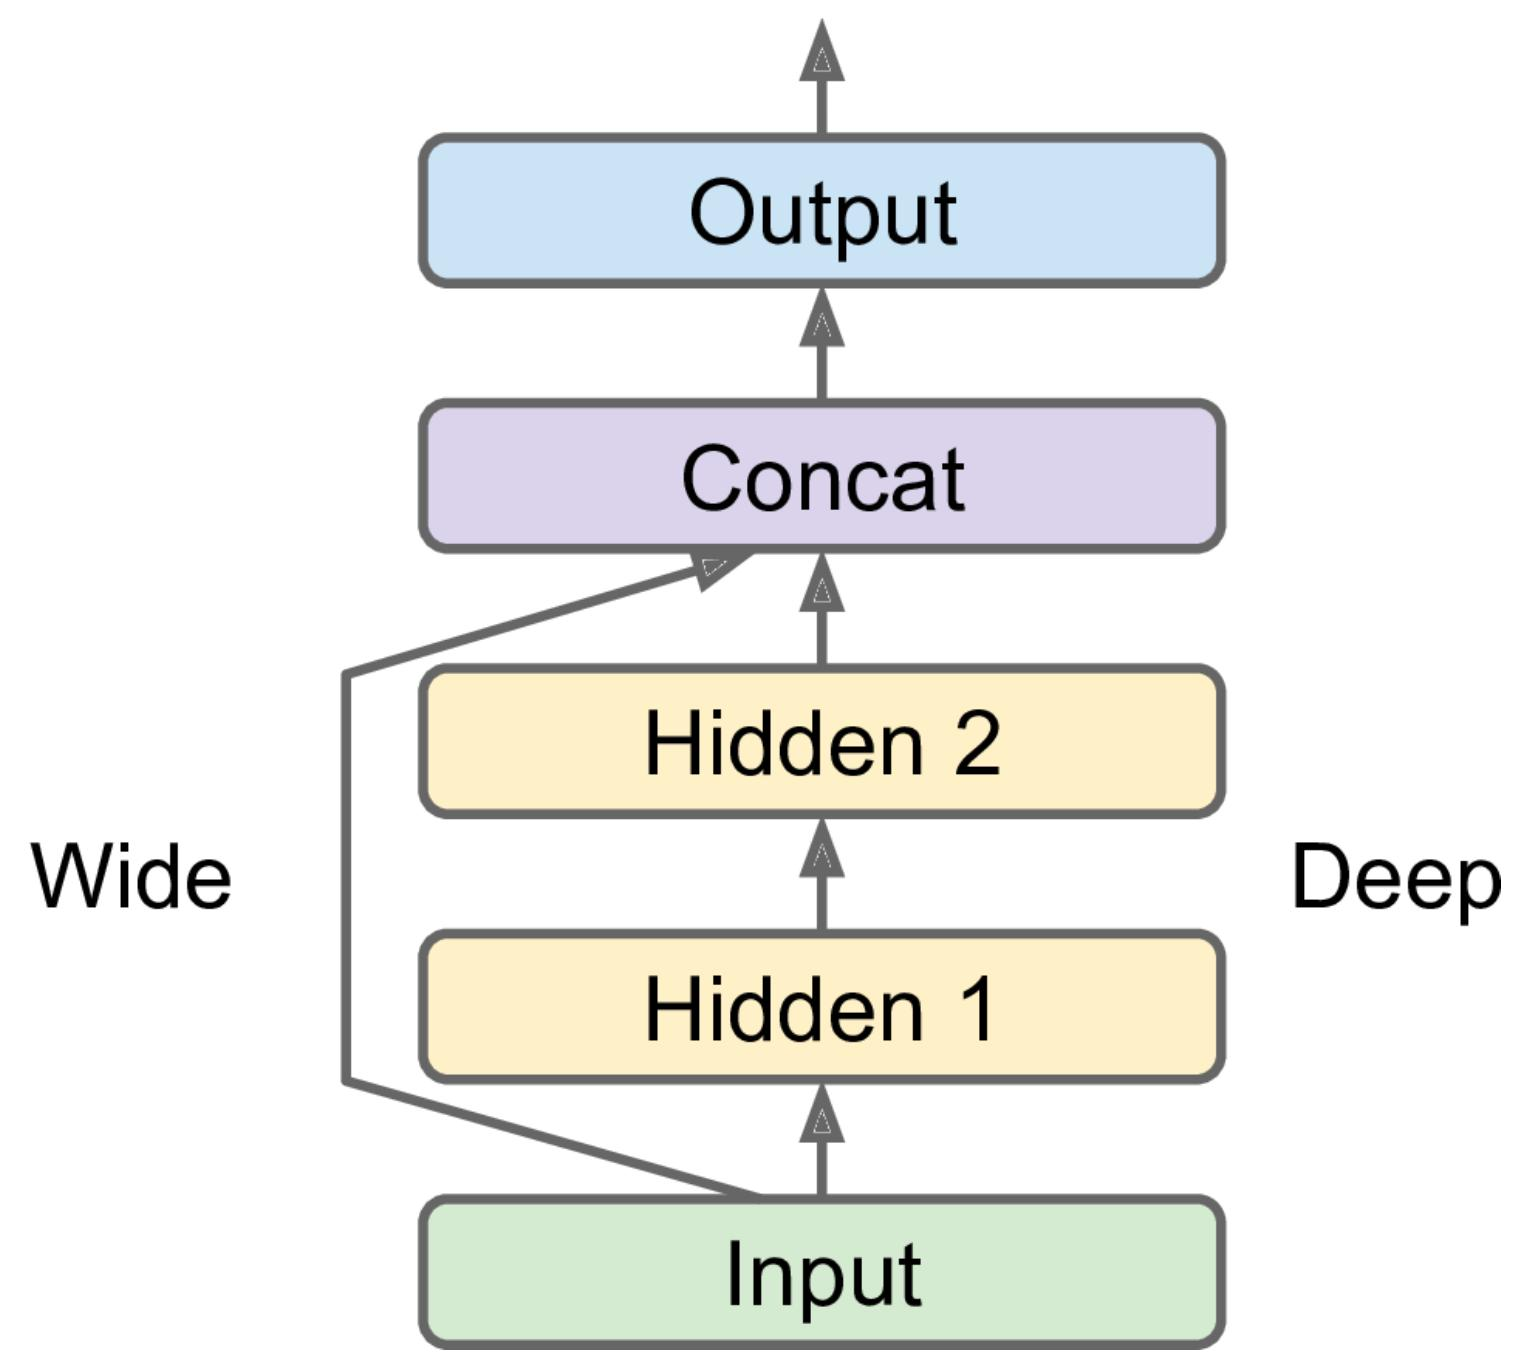

In [20]:
from IPython.display import Image, display

# Displaying Figure 10-13: Wide & Deep Architecture
display(Image(filename='/content/fig1.jpg'))